# 1. Conociendo las posibilidades

In [1]:
# importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1.1 ¿Podemos sacar conclusiones a partir de una muestra?

**¿Por qué podemos sacar conclusiones a partir de una muestra?** Para responder a esta pregunta, vamos realizar un experimento.

A continuación, tenemos tres conjuntos de datos diferentes que nos muestran diferentes formas de distribuciones:

* 1️⃣ **Edad de Jubilación**: Recopilamos datos de la edad de jubilación de una muestra, y al analizar el histograma de estas edades, observamos que hay una concentración en el rango medio de edades, pero algunas personas se jubilan más temprano.

* 2️⃣ **Tiempo de vida de una lámpara**: Es esencial para garantizar calidad, eficiencia energética y planificar estrategias de mantenimiento. Saber cuánto tiempo vive una lámpara nos permite ofrecer garantías confiables, se espera que pocas lámparas tengan un tiempo de vida corto (fallas prematuras), mientras que un tiempo de vida largo disminuye la probabilidad de que la lámpara dure.

* 3️⃣ **Altura de empleados**: Comprender la distribución de las alturas de los empleados es crucial para el diseño de un ambiente de trabajo ergonómico. Esto ayuda en la adaptación de estaciones de trabajo, sillas y equipos para garantizar comodidad y eficiencia.

In [2]:
# Lectura de los datos

# Edad de jubilación
datos_edad_jubilacion = pd.read_csv("/content/edad_jubilacion.csv")

# Tiempo de vida de una lámpara
datos_vida_lampara = pd.read_csv("/content/vida_util_foco.csv")

# Altura de los empleados
datos_alturas = pd.read_csv("/content/alturas.csv")

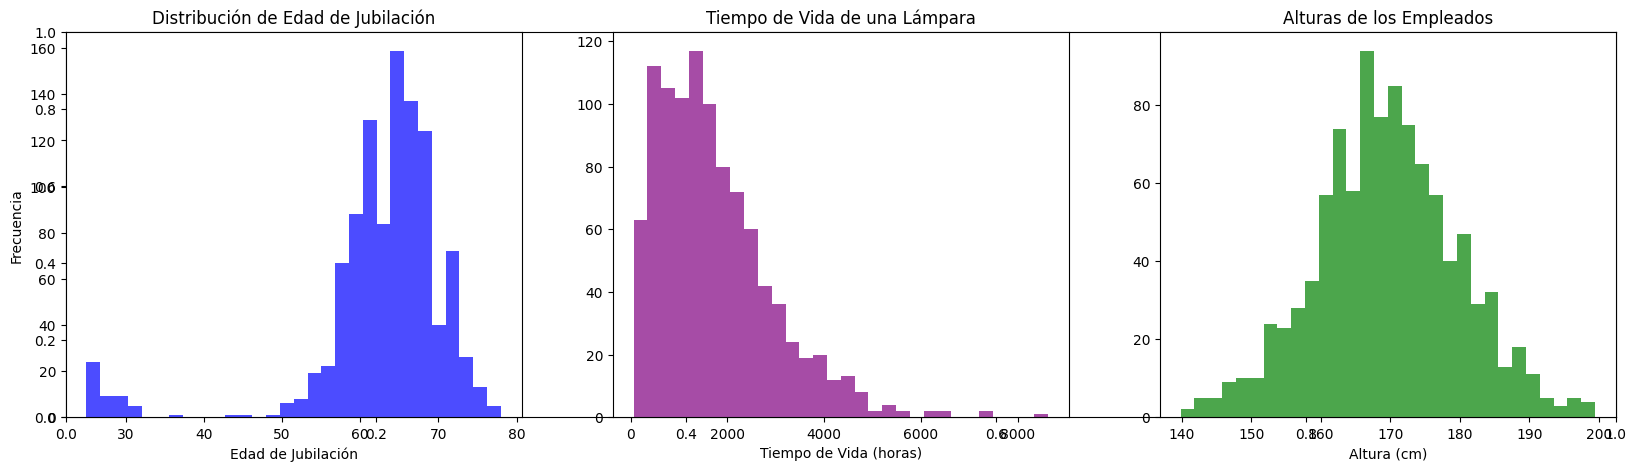

In [3]:
# Varias distribuciones
plt.subplots(figsize=(20, 5))
plt.subplot(131)
plt.title('Distribución de Edad de Jubilación')
plt.xlabel('Edad de Jubilación')
plt.ylabel('Frecuencia')
plt.hist(datos_edad_jubilacion, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(datos_vida_lampara, bins=30, alpha=0.7, color='purple')
plt.title('Tiempo de Vida de una Lámpara')
plt.xlabel('Tiempo de Vida (horas)')

plt.subplot(133)
plt.hist(datos_alturas, bins=30, alpha=0.7, color='green')
plt.title('Alturas de los Empleados')
plt.xlabel('Altura (cm)')

plt.show()

In [4]:
# Remuestreos

# tamaño de la muestra
n = 100
# cantidad de muestras
cant = 100000

# función de remuestreo y cálculo de medias
def remuestreo_media(datos, columna, n, cant):
  promedio = [datos[columna].sample(n, replace= True).mean() for _ in range(cant)]
  return promedio

In [5]:
# Realizando los remuestreos con la función
promedio_edad = remuestreo_media(datos_edad_jubilacion, 'edad', n, cant)
promedio_duracion = remuestreo_media(datos_vida_lampara, 'duracion', n, cant)
promedio_altura = remuestreo_media(datos_alturas, 'alturas', n, cant)

#### 1.2 **Población vs Muestra**
Vamos **comparar** ahora la distribución original con la distribución de las muestras, comparando la media de las distribuciones originales y la media de las medias muestrales.

In [6]:
print("*****  Promedios poblacionales *****")
print("edad:", datos_edad_jubilacion['edad'].mean())
print("duracion:", datos_vida_lampara['duracion'].mean())
print("altura:", datos_alturas['alturas'].mean())

*****  Promedios poblacionales *****
edad: 62.70857142857143
duracion: 1731.8036029420002
altura: 169.52022


In [7]:
def promedio(lst):
    return sum(lst) / len(lst)

print("*****  Promedios muestrales *****")
print("edad:", promedio(promedio_edad))
print("duracion:", promedio(promedio_duracion))
print("altura:", promedio(promedio_altura))


*****  Promedios muestrales *****
edad: 62.7082310000007
duracion: 1731.5405230593658
altura: 169.52390883500195


Las medias de las muestras están muy cerca de la media de las distribuciones originales. ¿Vamos a entender cómo se distribuyen las medias de las muestras?

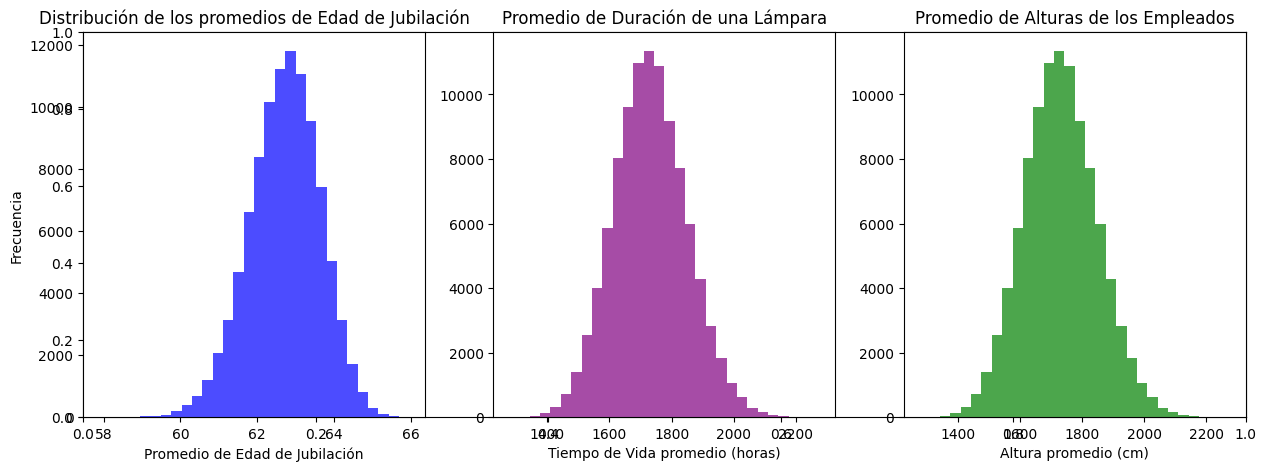

In [8]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribución de los promedios de Edad de Jubilación')
plt.xlabel('Promedio de Edad de Jubilación')
plt.ylabel('Frecuencia')
plt.hist(promedio_edad, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(promedio_duracion, bins=30, alpha=0.7, color='purple')
plt.title('Promedio de Duración de una Lámpara')
plt.xlabel('Tiempo de Vida promedio (horas)')

plt.subplot(133)
plt.hist(promedio_duracion, bins=30, alpha=0.7, color='green')
plt.title('Promedio de Alturas de los Empleados')
plt.xlabel('Altura promedio (cm)')

plt.show()

#### **Teorema del límite central**

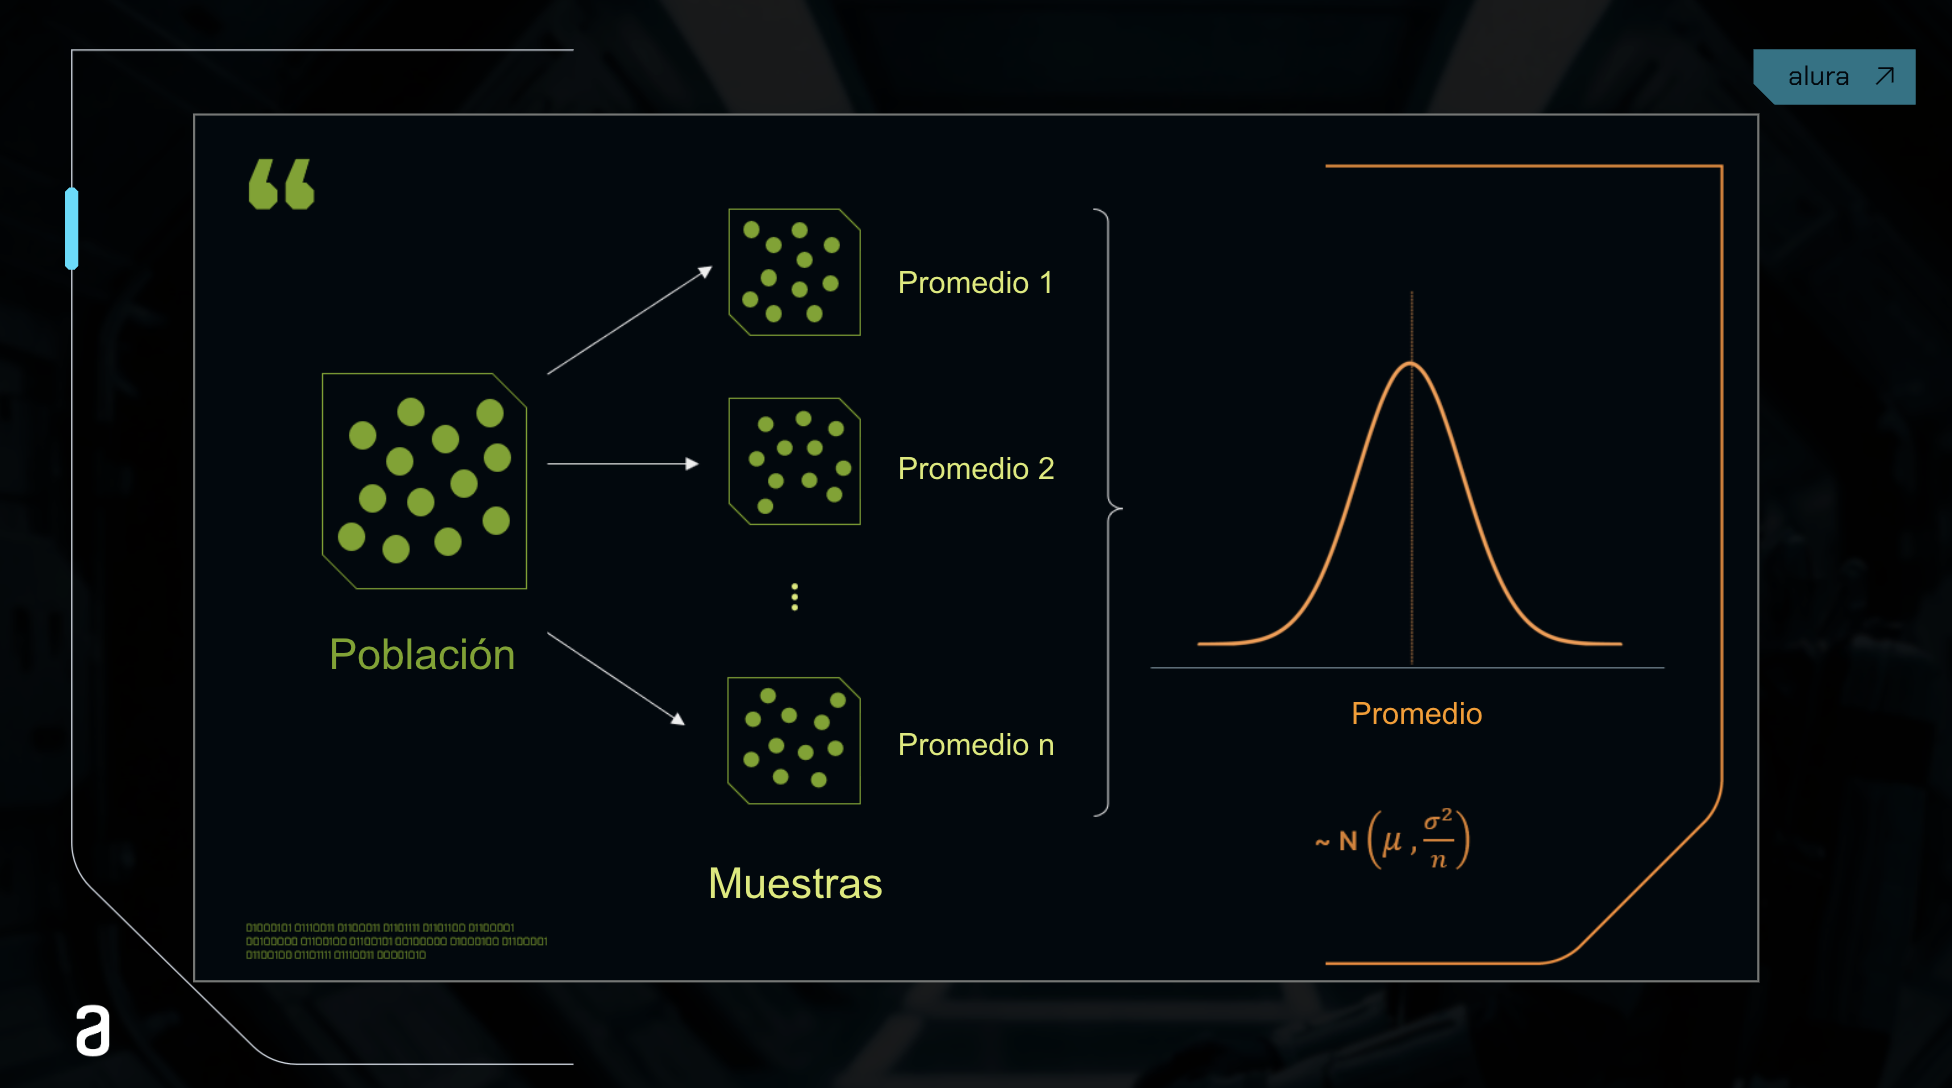

Observa que, independientemente de la distribución de origen, para n grande, observamos el mismo formato para la distribución de la media de las muestras. ¡Un formato de campana! ¡Esto no parece trivial, pero el Teorema del Límite Central nos lo dice!

Si analizamos que la **mayoría de las medias muestrales están cerca de la media de la distribución original**. Algunas serán más altas, otras serán más bajas.
Otro punto que el TLC nos dice es que, a mayor cantidad de muestras, la media muestral es más cercana.

Aquí volvemos a la pregunta inicial: **¿Podemos sacar conclusiones a partir de una muestra?** ¡Sí! Aquí vimos que las medias muestrales son muy cercanas a las medias de las distribuciones originales, pero también observamos que existe un riesgo de obtener una muestra con una media diferente a la población.

#### **✨ Actividad:** El efecto del tamaño de la muestra.

En el experimento anterior tomamos 1000 muestras de tamaño 100. ¿Y si cambiamos el tamaño? Reemplace el código de la actividad y ejecútelo. El gráfico está preparado para mostrarte la variabilidad de la media en relación a la cantidad de muestras.

## 1.3 ¿Qué tan confiables son nuestras conclusiones sobre la muestra?

¡La industria de lámparas nos contrató! Se realizó una nueva verificación de las lámparas recolectando la duración de otras lámparas. Ya sabemos que podemos inferir y sacar conclusiones a partir de esa muestra. Nos informaron que la duración promedio de este nuevo experimento fue de **1200 horas.**

> # CASO 1: CONTROL DE CALIDAD
La duración promedio de una muestra es 1200 horas. ¿Necesitamos activar el control de calidad?

In [9]:
# promedio de la nueva muestra
promedio_nueva_muestra = 1200
promedio_nueva_muestra

1200

In [10]:
# promedio original
promedio_poblacional = datos_vida_lampara['duracion'].mean()
promedio_poblacional

np.float64(1731.8036029420002)

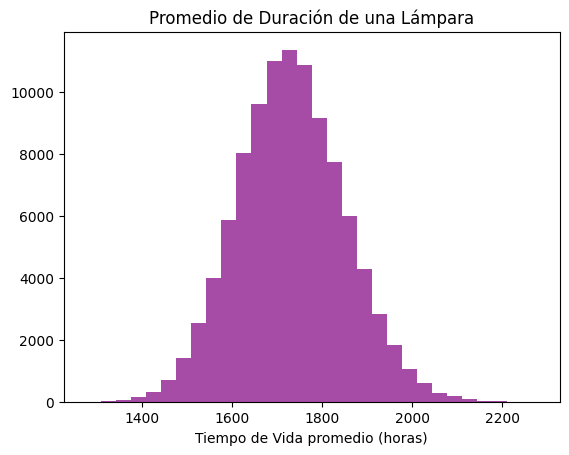

In [11]:
# ¿Qué tan lejos está este promedio del comportamiento?

plt.hist(promedio_duracion, bins=30, alpha=0.7, color='purple')
plt.title('Promedio de Duración de una Lámpara')
plt.xlabel('Tiempo de Vida promedio (horas)')
plt.annotate('.', xy=(promedio_nueva_muestra, 0), xytext=(promedio_nueva_muestra, 100), fontsize=8,
             arrowprops=dict(facecolor='green'))
plt.show()

Por el experimento anterior del TLC, sabemos que una lámpara dura en promedio 1732 horas, cuando nos enfrentamos al resultado de este nuevo experimento, vimos que la duración promedio de las lámparas es mucho menor de lo esperado, 1200 horas. Tu intuición te hace cuestionar:

* ¿Estos datos son correctos?
* ¿Estamos tratando con el mismo tipo de lámparas?
* Si todo es verdad, entonces parece que las lámparas de las fábricas necesitan pasar por el control de calidad de sus materiales.

Pero antes de informar tu intuición, otra pregunta queda en el aire: **¿qué tan seguro puedo pedir que verifiquen la calidad de las lámparas?** Para responder a esta pregunta, necesitamos entender qué tan lejos está la media de esta nueva muestra de la muestra poblacional.

Y para eso volvemos al experimento de las medias muestrales.

#### Distribución Normal

En la distribución normal, las medias muestrales generalmente se aproximan a la media verdadera. Sin embargo, la media puede variar entre muestras. El concepto de error estándar ayuda a entender esta variación sin la necesidad de visualizar un gráfico.

In [12]:
# transformando promedios_duracion en DataFrame
duracion_muestras = pd.DataFrame({'promedios_duracion': promedio_duracion})

In [13]:
# calculando información
promedio_de_promedios = duracion_muestras['promedios_duracion'].mean()
EE = duracion_muestras['promedios_duracion'].std()

print("*****  Medidas muestrales *****")
print("promedio:", promedio_de_promedios)
print("Error Estándar:", EE)

*****  Medidas muestrales *****
promedio: 1731.5405230593701
Error Estándar: 118.33787056469801


In [14]:
# ¿Cuántos errores?
1732 - 3*EE

1376.986388305906

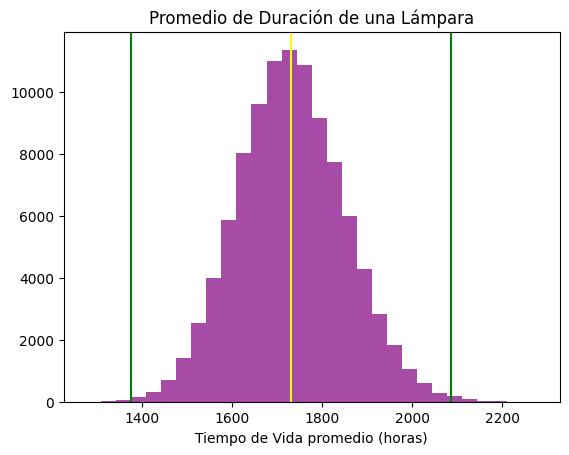

In [15]:
# Visualizando la cantidad de muestras entre 3EP +- del promedio.

plt.hist(promedio_duracion, bins=30, alpha=0.7, color='purple')
plt.title('Promedio de Duración de una Lámpara')
plt.xlabel('Tiempo de Vida promedio (horas)')
plt.axvline(promedio_de_promedios, color="yellow")
plt.axvline(promedio_de_promedios + 3*EE, color="green")
plt.axvline(promedio_de_promedios - 3*EE, color="green")
plt.annotate('.', xy=(promedio_nueva_muestra, 0), xytext=(promedio_nueva_muestra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

Este sentido de variabilidad nos brinda la noción del nivel de confianza de decisiones basadas en muestras. Volviendo al nuevo experimento, 1200 horas promedio para las nuevas lámparas es mucho menos que 3 errores estándar. Gracias al poder de este formato simétrico, podemos entender cuántas medias están a tres EP más o menos, pero ¿qué significa esto? Para ello vamos a contar las observaciones en este intervalo.

In [16]:
# cuántas observaciones están en el intervalo de +/- tres desviaciones
cant_obs = duracion_muestras[(duracion_muestras > promedio_de_promedios - 3*EE) &
                              (duracion_muestras < promedio_de_promedios + 3*EE)].count()

# ¿cuánto representa esto?
cant_obs / duracion_muestras.count() * 100

,0
promedios_duracion,99.707


Esto indica que si los datos son correctos y estamos hablando del mismo tipo de lámparas, podemos informar al control de calidad la verificación a un nivel de confianza del 99.7%.

### Nivel de confianza

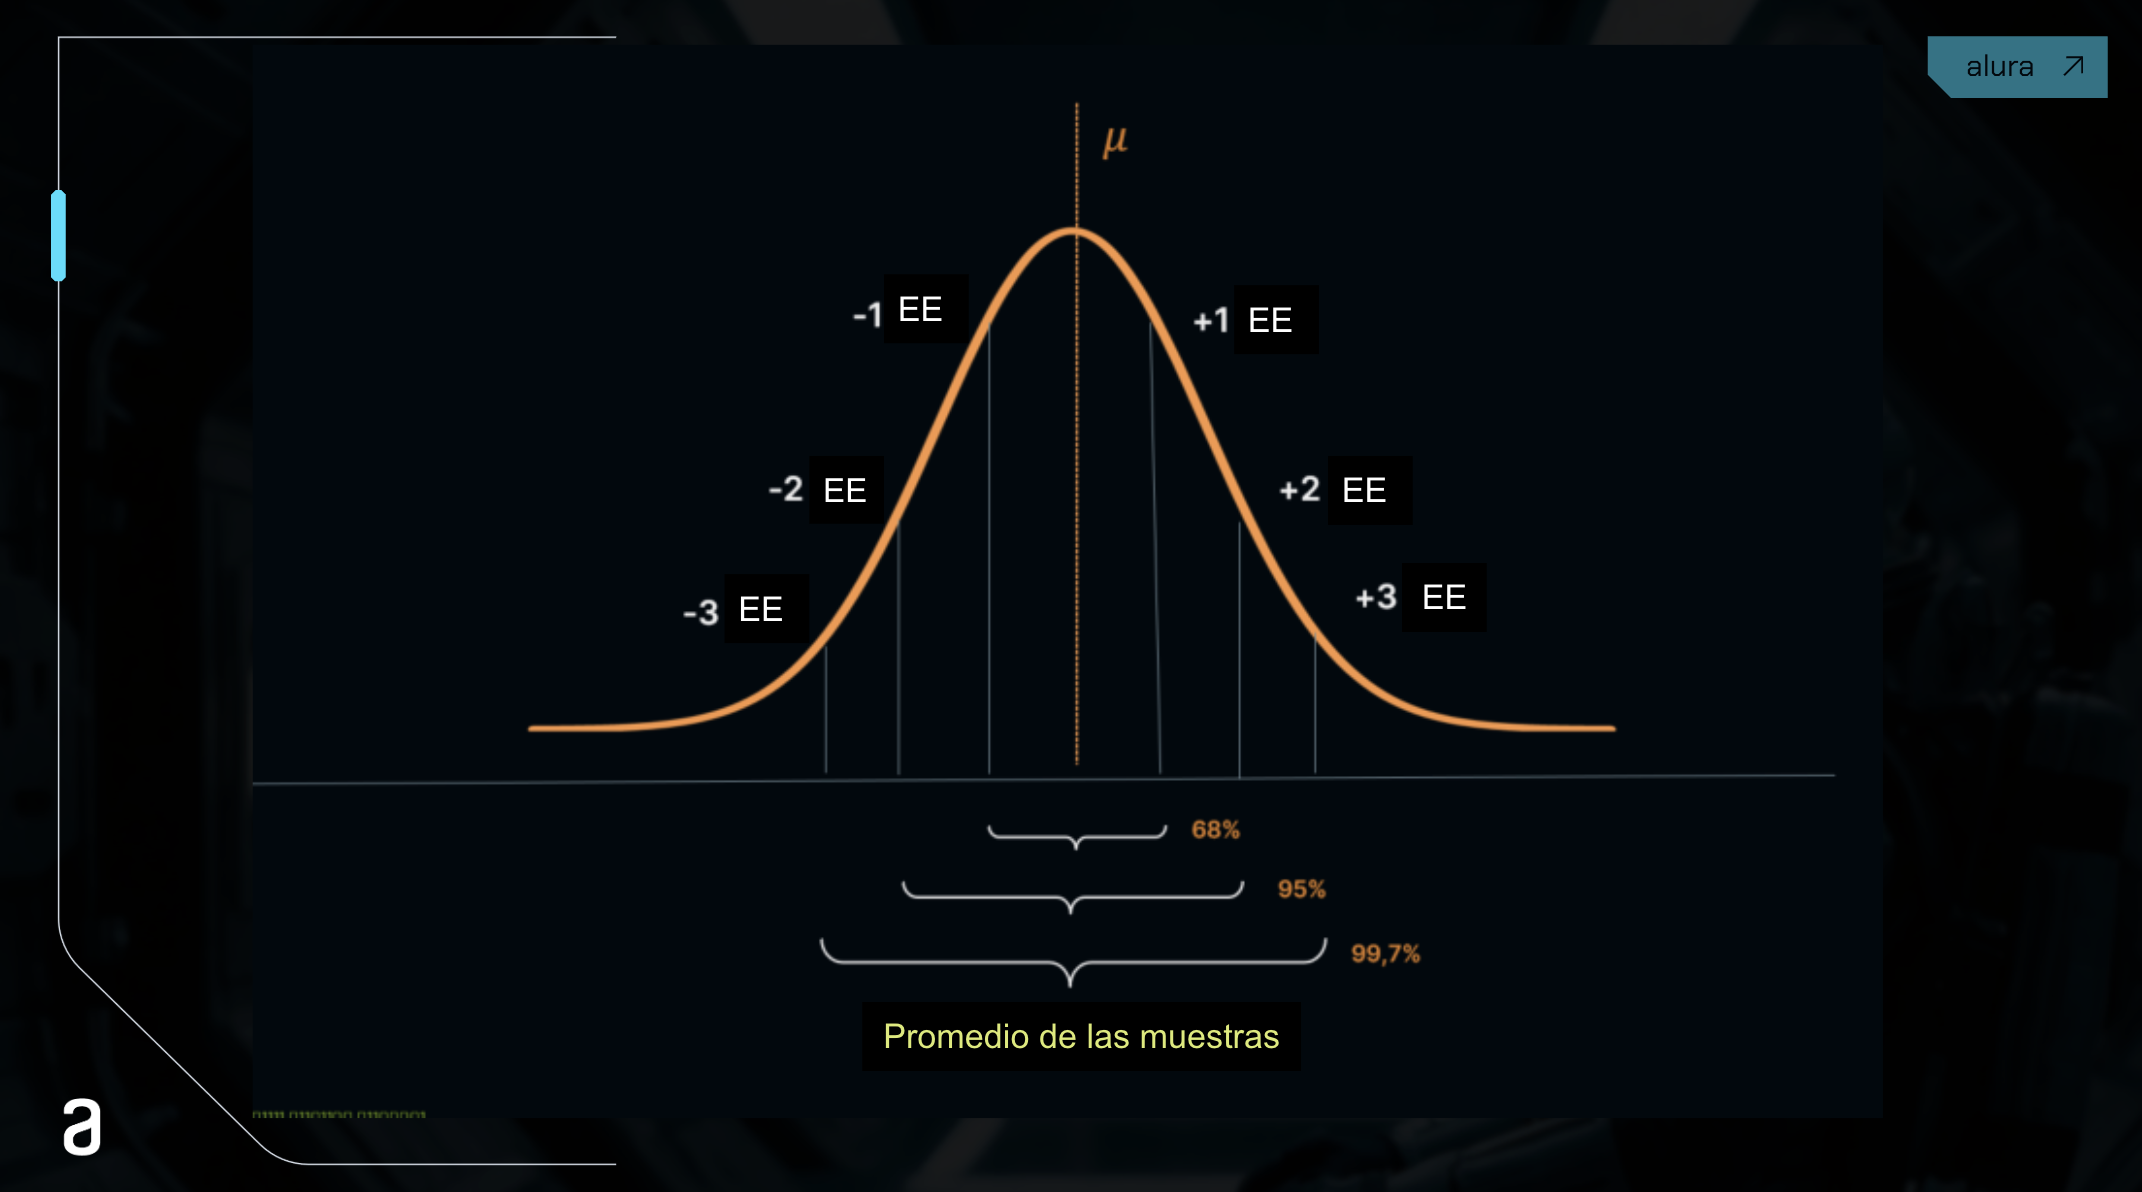

Gracias a la distribución normal, el nombre para este formato de campana, este patrón es esperado, es decir, esperamos que:
* El 68% de todas las medias muestrales se encuentren dentro de un error estándar con respecto a la media poblacional;
* El 95% de las medias muestrales están dentro de dos EE y;
* El 99,7% de las medias de muestras están entre 3 EE en relación a la media poblacional.

Este patrón cuantifica entonces el nivel de confianza tomado en consideración en los análisis muestrales.

## 1.4 Estableciendo un intervalo de confianza

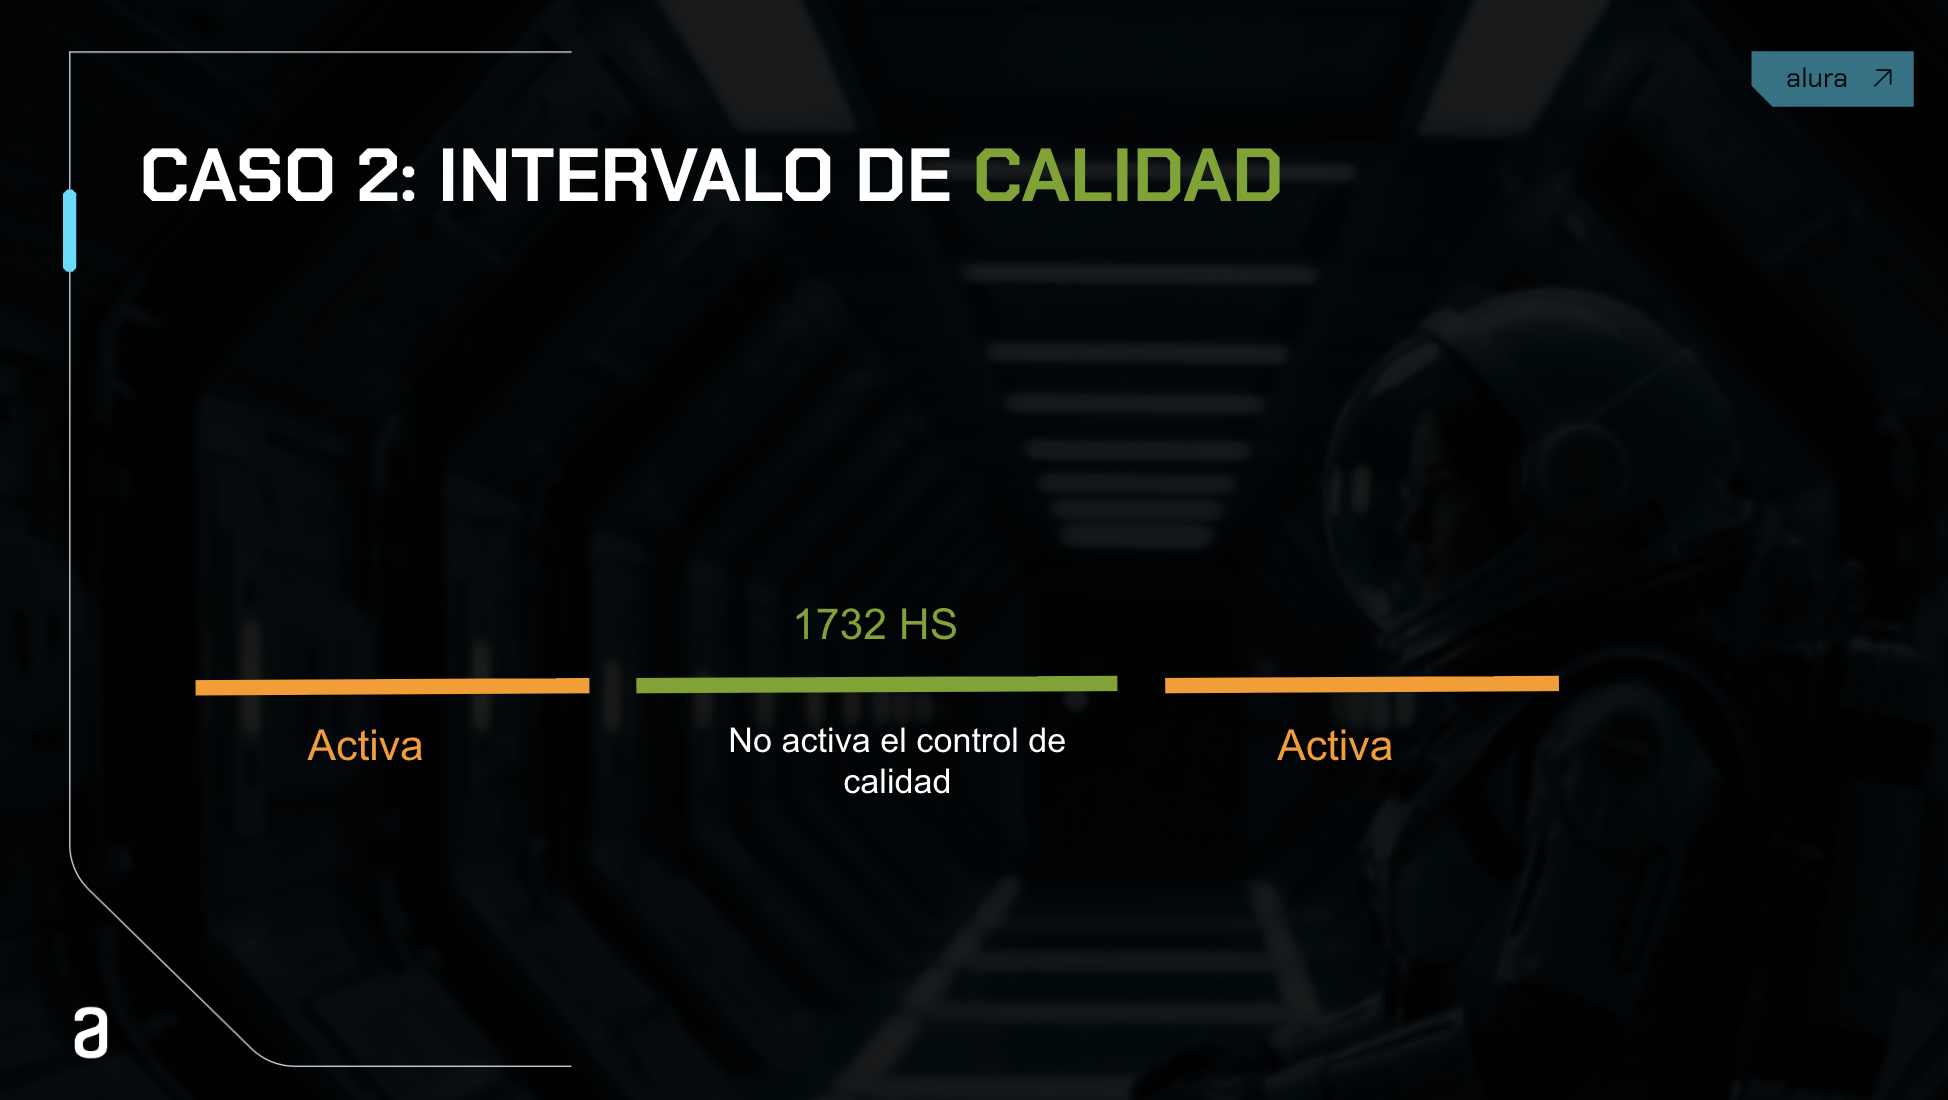

Para establecer un intervalo que contenga la verdadera duración promedio de las lámparas, vamos a tener en cuenta 3 aspectos:

* La duración promedio
* El nivel de confianza
* La variabilidad de mis datos.

En este intervalo vamos a agregar un margen de error en la media, considerando así el nivel de confianza y la variabilidad de los datos.

Aquí en python, vamos a importar la biblioteca para ayudarnos en este cálculo.

In [17]:
from scipy import stats

In [18]:

# tomar en cuenta esta muestra
datos_vida_lampara

# nivel de confianza definido
confianza = 0.95

Podemos establecer el nivel de confianza en 0.95, esto significa, según el TCL, que para 95 muestras de cada 100, la media de la muestra estará dentro de dos EE de la media real. El nivel de confianza es un criterio que debe ser establecido junto a los tomadores de decisiones, ya que está relacionado con el error y la restricción de este intervalo.

In [19]:
# información para el IC

promedio = datos_vida_lampara['duracion'].mean()
desvio_estandar_muestral = datos_vida_lampara['duracion'].std()
tamano_muestra = len(datos_vida_lampara)

In [20]:
promedio

np.float64(1731.8036029420002)

In [38]:
# Calculando intervalo de confianza
intervalo_confianca = stats.norm.interval(confianza,
                                          loc=promedio,
                                          scale=desvio_estandar_muestral/np.sqrt(tamano_muestra))

In [40]:
print(f'Intervalo de Confianza (95%): {intervalo_confianca}')

Intervalo de Confianza (95%): (np.float64(1658.3741665835485), np.float64(1805.233039300452))


Este resultado nos dice que con un 95% de confianza, la verdadera media de la duración de las lámparas está contenida en el intervalo de (1658.28 horas, 1805.32 horas), a partir de la muestra analizada.

# 2. Prueba para una muestra

> # Caso 3: Establecer la duración: Fuimos contratados para otro proyecto en la industria de las luces, pero esta vez para determinar si la duración promedio de todas las luces de Navidad de la marca es igual o diferente de 1570 horas. Además, analise el riesgo.

## 2.1 Formulando la hipotesis

Una hipótesis es una afirmación sobre un parámetro de la población — por ejemplo, la duración promedio de una lámpara. No es una certeza, es una suposición que vamos a poner a prueba con datos.


In [29]:
# hipotesis nula
hipotesis_duracion_promedio = 1570

Establecidas las hipótesis,

$H_0 : \mu = 1570$\
$H_1 : \mu \neq 1570$

podemos identificar el criterio para rechazar o no la hipótesis establecida, pero antes vamos a conocer nuestra región crítica, el criterio de rechazo.

## 2.2 Estableciendo la regla de decisión

Para tomar esta decisión y calcular la probabilidad de estar cometiendo un error, necesitamos considerar una regla de decisión, es decir, entender cuándo vamos a asumir que Ho es rechazada.

Para esta regla, podemos tener en cuenta un concepto que ya hemos visto aquí, el intervalo de confianza, que establece un margen de error para la media a partir de un nivel de confianza en la variabilidad de los datos.

In [30]:
# datos muestrales
muestra_lampara = pd.read_csv("/content/experimento_luces_navidenas.csv")

# promedio muestral
promedio_muestral = muestra_lampara['duracion'].mean()

In [31]:
promedio_muestral

np.float64(1529.5081310675512)

In [32]:
# información para la región crítica

confianza = 0.95 # nivel de confianza deseado
desvio_estandar_poblacional = 105 # sigma dado por la fábrica
tamano_muestra = len(muestra_lampara)

In [33]:
# calculando el IC
from scipy import stats
intervalo_confianza = stats.norm.interval(confianza,
                                          loc=1570,
                                          scale=(desvio_estandar_poblacional)/np.sqrt(tamano_muestra))
print(f'Intervalo de Confianza de 95%: {intervalo_confianza}')

Intervalo de Confianza de 95%: (np.float64(1549.4203781623294), np.float64(1590.5796218376706))


Este es el intervalo de confianza, establecido por la muestra al 95% de confianza bajo H₀.

In [34]:
promedio_muestral

np.float64(1529.5081310675512)

Calculando la media muestral, obtenemos 1530.30 horas, este valor no está contenido en la región de aceptación. Es decir, no podemos decir que la duración media de las lámparas es de 1570 con un 95% de confianza.

  Pero ¿cuál es la probabilidad de rechazar incorrectamente Ho? Para esto necesitamos entender los errores asociados a esta decisión.

## 2.3 Errores asociados a pruebas de hipótesis
Cualquiera sea la decisión tomada, estamos sujetos a cometer errores: \
El error de rechazar Ho cuando en realidad es verdadera, y el error de no rechazar Ho cuando es falsa.

In [ ]:
# nivel de significancia: cuando rechazas erróneamente la hipótesis nula cuando en realidad es verdadera.
confianza
nivel_significancia = round(1 - confianza, 2) # riesgo del 5% de rechazar la hipótesis nula, aunque sea verdadera.
nivel_significancia

0.05

## 2.4 ¿En qué intensidad estamos rechazando la hipótesis?

Ten en cuenta que hasta ahora hemos establecido un nivel de confianza para interpretar nuestros resultados, sin embargo, nuestra decisión puede cambiar dependiendo del rigor de confianza que establezcamos.

In [43]:
from statsmodels.stats.weightstats import ztest

In [45]:
stat, p_valor = ztest(x1=muestra_lampara['duracion'], value=1570, alternative='two-sided')


In [46]:
muestra_lampara['duracion'].mean()

np.float64(1529.5081310675512)

In [47]:
# Muestra los resultados
print(f'Estadístico Z: {stat}')
print(f'Valor-p {p_valor}')


Estadístico Z: -45.732770207263556
Valor-p 0.0


In [48]:
# Verifica la hipótesis nula con base en el valor-p
if p_valor < 0.05:
    conclusion = "Rechazar la hipótesis nula"
else:
    conclusion = "No rechazar la hipótesis nula"

print("Conclusión:", conclusion)

Conclusión: Rechazar la hipótesis nula


**estadistica_z:** El signo negativo sugiere que la media de la muestra está por debajo de la media poblacional hipotética.

**p_valor:** 0.00. Esto representa la probabilidad de obtener una estadística Z tan o más extrema que la observada, asumiendo que la hipótesis nula es verdadera. Hay una probabilidad del 0.08% de observar una media de muestra tan o más discrepante de la media hipotética.

# 3. Prueba para una muestra pequeña

## 3.1 Formulando la hipótesis



> # **Caso 4:** Una empresa de software está interesada en verificar si el tiempo promedio de respuesta de su soporte técnico es **menor a 30 minutos**, como se prometió en el acuerdo de nivel de servicio (SLA). Ellos recopilan datos sobre el tiempo de respuesta para una muestra de 25 solicitudes de soporte.

In [49]:
# Tiempo de respuesta en minutos para 25 solicitudes de soporte
tiempo_respuesta = [28, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                    30, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                    30, 32, 24, 29, 30]

Establecidas las hipótesis:

$H_0 : \mu = 30$\
$H_1 : \mu \leq 30$

Seguimos con la prueba, y esta vez no tenemos información sobre la población. ¿Qué prueba podemos seguir?

## 3.2 Aplicando el Test T


Cuando no tenemos información sobre la variabilidad de nuestra población, especialmente cuando nuestra muestra es pequeña. Seguimos con un test t, que sigue el mismo principio del test z.

In [50]:
# promedio recolectado del tiempo
np.mean(tiempo_respuesta)

np.float64(29.96)

In [51]:
# importando ttest_1samp
from scipy.stats import ttest_1samp

In [52]:
# Realiza el test t unilateral para una muestra
stat, p_valor = ttest_1samp(tiempo_respuesta, 30, alternative = 'less')




In [54]:
# Muestra los resultados
print(f'Estadístico del test: {stat}')
print(f"Valor-p: {p_valor}")

Estadístico del test: -0.10506930292746224
Valor-p: 0.4585970095667924


## 3.3 Interpretando el Test T

![](https://i.imgur.com/3yvNUJR.png)

In [55]:
nivel_significancia =  0.05 # alpha

if p_valor < nivel_significancia:
    conclusion = "Rechazar la hipótesis nula"
else:
    conclusion = "No rechazar la hipótesis nula"

conclusion

'No rechazar la hipótesis nula'

# 4. Prueba para dos muestras

## 4.1 muestras independientes

> # Caso 5 : Estamos brindando consultoría a una empresa de comercio electrónico, y en medio de una reunión surge una hipótesis: "La publicidad tiene un efecto positivo en las ventas". ¿Podemos agregar más publicidad en el sitio para aumentar las ventas?

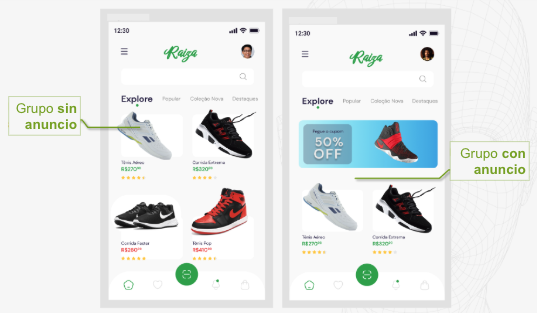

In [56]:
ventas_con_publicidad = [329.80, 291.70, 338.86, 391.38,
                         285.95, 285.95, 394.75, 346.05,
                         271.83, 332.55, 272.19, 272.06,
                         314.52, 185.20, 196.50, 266.26,
                         239.23, 318.85, 245.52, 215.26,
                         387.94, 286.45, 304.05, 214.52,
                         267.34, 306.66, 230.94, 322.54,
                         263.96, 282.50, 263.90, 411.14,
                         299.19, 236.54, 349.35, 226.75,
                         312.53, 182.42, 220.31, 311.81,
                         344.31, 310.28, 293.06, 281.93,
                         211.29, 256.81, 272.36, 363.43,
                         320.62, 194.22]

In [57]:
ventas_sin_publicidad = [304.44, 261.89, 244.38, 321.70,
                         346.86, 340.88, 234.65, 266.45,
                         304.88, 343.53, 256.25, 273.86,
                         218.62, 213.23, 333.75, 366.37,
                         280.68, 345.21, 306.70, 246.29,
                         306.68, 377.28, 282.85, 378.88,
                         127.82, 334.31, 290.22, 267.06,
                         290.51, 165.74, 271.82, 306.43,
                         373.67, 253.90, 236.49, 254.89,
                         339.92, 304.73, 253.21, 315.80,
                         290.82, 343.12, 242.88, 265.34,
                         261.47, 197.19, 302.77, 300.66,
                         285.31, 270.92]

In [ ]:
# promedio con publicidad


# promedio sin publicidad


In [ ]:
# Crear histogramas

# Agregar etiquetas y título
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.title('Histograma de Ventas con y sin Publicidad')
plt.legend()
plt.show()

Hipotesis de esta prueba de muestras independientes:\
H_0: media_sin = media_con\
H_1: media_sin < media_con

In [61]:
# test t para muestras independientes (ttest_ind)


In [62]:
# Aplicación del test t de Student para muestras independientes


In [ ]:
# Visualización de los resultados


In [ ]:
# Interpretación de los resultados
alpha = 0.05
if p_valor < alpha:
    print("Rechazar la hipótesis nula: Hay evidencias de que la publicidad tiene un efecto positivo en las ventas.")
else:
    print("No rechazar la hipótesis nula: No hay evidencias suficientes para afirmar un efecto positivo en las ventas debido a la publicidad.")

## 4.2 Muestras emparejadas/pareadas


> # Caso 6: Programa de entrenamiento del equipo de atención al cliente del comercio electrónico desea evaluar el impacto de un programa de entrenamiento en su desempeño. La empresa recopiló datos de evaluaciones de desempeño antes y después del entrenamiento para los mismos empleados. Desean determinar si hay una diferencia significativa en las evaluaciones antes y después del entrenamiento.

In [65]:
antes_del_entrenamiento = [78, 65, 75, 80, 85, 88, 79, 81, 76, 84]
despues_del_entrenamiento = [85, 70, 75, 87, 90, 92, 84, 82, 76, 91]

In [ ]:
# Comparando antes y después
resultado_resta = [b - a for a, b in zip(antes_del_entrenamiento, despues_del_entrenamiento)]

print()

Hipotesis de esta prueba de muestras pareadas:\
$H_0: μ_d = 0$\
$H_1: μ_d > 0 $

$μ_d$ es la media de las diferencias de los pares.

In [73]:
# importando el test pareado ttest_rel


In [ ]:
# Aplicando el test t pareado


# 5. Pruebas no paramétricas

## 5.1 limitaciones de las pruebas paramétricas

* Datos con valores atípicos influyentes
* No hace suposiciones sobre la distribución
* Se utilizan cuando tenemos muestras muy pequeñas y no podemos identificar la distribución de los datos
* Análisis cualitativo

## 5.2 Aplicando test de Mann-Whitney


> # Caso 7: Comparar la eficacia de dos metodologías de entrenamiento físico, llamadas Entrenamiento A y Entrenamiento B, en términos de mejora en el rendimiento atlético. Los participantes del estudio fueron divididos aleatoriamente en dos grupos, uno sometido al Entrenamiento A y el otro al Entrenamiento B. Se registró la ganancia de fuerza de cada individuo que realizó el Entrenamiento A y de aquellos que realizaron el Entrenamiento B

In [77]:
# Datos de desempeño de los dos grupos
entrenamiento_a = [5, 3, 8, 4, 6]
entrenamiento_b = [4, 2, 7, 5, 3]

In [75]:
# Importando test mannwhitneyu


H0​ : Las distribuciones de las dos poblaciones son iguales.

H1​ : Las distribuciones de las dos poblaciones son diferentes.

In [78]:
# Aplicando el test de Mann-Whitney


In [ ]:
# H0 es que A y B tengan la misma distribución

# Cuanto más bajo sea el valor de U, mayor será la evidencia de que las poblaciones son diferentes.

## 5.3 Utilizando el test de Wilcoxon

> # Caso 8: El gimnasio realizó una reorganización en la disposición de los equipos, cambiando de un Layout A a un Layout B, y desea evaluar si ese cambio tuvo un impacto significativo en las preferencias de los usuarios. El gimnasio está interesado en comparar la preferencia de los clientes antes y después del cambio.

**Muestras pareadas**

In [81]:
# Preferencias de los usuarios antes y después del cambio de layout
preferencias_antes = [4, 2, 5, 2, 5, 6, 7, 8, 9, 10]
preferencias_despues = [8, 5, 3, 5, 8, 9, 9, 9, 10, 9]

In [ ]:
# diferencias de percepción
resultado_resta = [b - a for a, b in zip(preferencias_antes, preferencias_despues)]

print()

In [ ]:
# Promedio y mediana


H0​: La mediana de las diferencias entre los pares es cero.

H1​: La mediana de las diferencias entre los pares no es cero.

In [84]:
# Importando test de wilcoxon


In [ ]:
# Realiza el test de Wilcoxon para muestras pareadas


# Muestra los resultados
